In [1]:
import os
import glob
import gc
import random
import re

import numpy as np
import pandas as pd

from scipy.stats import median_abs_deviation, percentileofscore
import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData, MultimodalData

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [26]:
PATH = '/mnt/sdb/scz_meta_analysis_processed/anndata_objs/'

In [2]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')

adata_hvg = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_hvg.h5ad')

In [11]:
## Port Embeddings From HVG Anndata Obj To Full ##

adata.obsm = adata_hvg.obsm
adata.obsp = adata_hvg.obsp

In [22]:
isinstance(adata, UnimodalData)

True

In [25]:
## First Round Clustering ##

if ~isinstance(adata, UnimodalData):
    adata = UnimodalData(adata)

# already calculatd neighbors off scVI space
pg.leiden(adata, rep='scVI', resolution=0.1, class_label='class')
plt.show()

# create scanpy anndata object
adata = adata.to_anndata()

2026-02-25 09:27:17,599 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 15.55s.
2026-02-25 09:37:57,824 - pegasus.tools.clustering - INFO - Leiden clustering is done. Get 3 clusters.
2026-02-25 09:37:58,196 - pegasus.tools.clustering - INFO - Function 'leiden' finished in 656.15s.


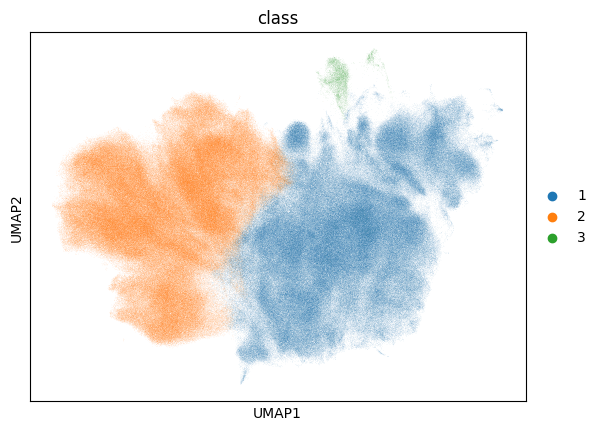

In [27]:
sc.pl.umap(adata, color='class')

In [ ]:
def subcluster(
    anndata_object_filename,
    hvg_number=3000, resolution=0.1, class_label="class", new_class_label="subclass"):

    # ------------------------------------------------------------------
    # 1. Split original object by class and write to disk
    # ------------------------------------------------------------------

    input_path = os.path.join(PATH, anndata_object_filename)
    split_dir = os.path.join(PATH, class_label)
    os.makedirs(split_dir, exist_ok=True)

    adata = sc.read_h5ad(input_path, backed="r")
    groups = adata.obs[class_label].unique()

    for group in groups:
        subset = adata[adata.obs[class_label] == group]
        out_file = os.path.join(split_dir, f"{class_label}_{group}.h5ad")
        subset.copy(filename=out_file)
        gc.collect()

    del adata
    gc.collect()

    # ------------------------------------------------------------------
    # 2. Process each class-specific file
    # ------------------------------------------------------------------

    pattern = re.compile(rf"^{re.escape(class_label)}(_\d{{1,2}})+\.h5ad$")
    file_list = [
        f for f in glob.glob(os.path.join(split_dir, f"{class_label}_*.h5ad"))
        if pattern.match(os.path.basename(f))
    ]

    print(file_list)

    for file_path in file_list:

        print(f"Processing: {file_path}")

        adata_cluster = sc.read_h5ad(file_path, backed="r")

        # ---- HVG calculation (protein-coding autosomal genes only) ----
        hvg_file = file_path.replace(".h5ad", "_protein_coding_autosome.h5ad")

        adata_cluster[      :, adata_cluster.var.robust_protein_coding_autosome
        ].copy(filename=hvg_file)

        integrated_hvg = sc.read_h5ad(hvg_file, backed="r")

        hvg = sc.pp.highly_variable_genes(integrated_hvg, layer="log1p_norm", n_top_genes=hvg_number, inplace=False, subset=False)

        hvg_list = integrated_hvg.var.index[hvg.highly_variable].tolist()

        del integrated_hvg
        gc.collect()

        # Apply HVG list back to original cluster object
        adata_cluster.var["highly_variable_features"] = adata_cluster.var.index.isin(hvg_list)

        # ------------------------------------------------------------------
        # PCA
        # ------------------------------------------------------------------

        pg.pca(adata_cluster, n_components=30)

        sc.pl.pca_variance_ratio(adata_cluster, n_pcs=30, log=True)
        sc.pl.pca_scatter(adata_cluster, color="total_counts")
        plt.show()

        explained = adata_cluster.uns["pca"]["variance_ratio"].sum() * 100
        print(f"There is {explained:.2f}% variance explained by these components")

        post_pca_file = file_path.replace(".h5ad", "_post_pca.h5ad")
        adata_cluster.write_h5ad(post_pca_file)

        del adata_cluster
        gc.collect()

        # ------------------------------------------------------------------
        # Regression, Harmony, Clustering
        # ------------------------------------------------------------------

        adata_cluster = pg.read_input(post_pca_file)

        pg.regress_out(adata_cluster, ["total_counts", "pct_counts_mito", "cycle_diff"])

        pg.run_harmony(adata_cluster, batch="batch", rep="pca_regressed", max_iter_harmony=20, n_comps=30)

        pg.neighbors(adata_cluster, rep="pca_regressed_harmony", use_cache=False, dist="l2", K=100, n_comps=30)

        pg.leiden(adata_cluster, rep="pca_regressed_harmony", resolution=resolution, class_label=new_class_label)

        # ------------------------------------------------------------------
        # Save subcluster labels
        # ------------------------------------------------------------------

        label_dir = os.path.join(PATH, f"{new_class_label}_labels")
        os.makedirs(label_dir, exist_ok=True)

        label_file = os.path.join(
            label_dir,
            os.path.basename(file_path).replace(".h5ad", "_subclustered.csv"),
        )

        adata_cluster.obs[[new_class_label]].to_csv(label_file)

        del adata_cluster
        gc.collect()

    # ------------------------------------------------------------------
    # 3. Merge subcluster labels back to original integrated dataset
    # ------------------------------------------------------------------

    integrated = sc.read_h5ad(input_path)

    label_files = glob.glob(os.path.join(label_dir, "*"))

    subclustered_labels = [pd.read_csv(f) for f in label_files]
    subclustered_df = pd.concat(subclustered_labels)

    subclass_dict = dict(zip(subclustered_df["barcodekey"], subclustered_df[new_class_label]))

    integrated.obs[new_class_label] = pd.Series(integrated.obs.index).map(subclass_dict).values


    integrated.obs[f"{class_label}_{new_class_label}"] = (
        integrated.obs[class_label].astype(str) + "_" + integrated.obs[new_class_label].astype(str))

    output_path = os.path.join(PATH, anndata_object_filename.replace(".h5ad", f"_{new_class_label}_breakdown.h5ad"))

    integrated.write_h5ad(output_path)

    del integrated
    gc.collect()

In [ ]:
def split_by_class(input_path, split_dir, class_label):
    """Split AnnData object into per-class files."""
    os.makedirs(split_dir, exist_ok=True)

    adata = sc.read_h5ad(input_path, backed="r")
    groups = adata.obs[class_label].unique()

    output_files = []

    for group in groups:
        subset = adata[adata.obs[class_label] == group]
        out_file = os.path.join(split_dir, f"{class_label}_{group}.h5ad")
        subset.copy(filename=out_file)
        output_files.append(out_file)

    del adata
    gc.collect()

    return output_files

In [ ]:
def subcluster_file(file_path, resolution, new_class_label):
    """Perform HVG selection, PCA, regression, Harmony, and Leiden clustering."""
    
    print(f"Processing: {file_path}")
    adata = sc.read_h5ad(file_path, backed="r")

    # ---- HVGs (protein-coding autosomal only) ----
    hvg_file = file_path.replace(".h5ad", "_protein_coding_autosome.h5ad")

    adata[:, adata.var.robust_protein_coding_autosome].copy(filename=hvg_file)
    integrated_hvg = sc.read_h5ad(hvg_file, backed="r")

    hvg = sc.pp.highly_variable_genes(integrated_hvg, layer="log1p_norm", n_top_genes=2000, inplace=False, subset=False)

    hvg_list = integrated_hvg.var.index[hvg.highly_variable].tolist()

    del integrated_hvg
    gc.collect()

    adata.var["highly_variable_features"] = adata.var.index.isin(hvg_list)

    # ---- PCA ----
    pg.pca(adata, n_components=30)

    explained = adata.uns["pca"]["variance_ratio"].sum() * 100
    print(f"{explained:.2f}% variance explained")

    post_pca_file = file_path.replace(".h5ad", "_post_pca.h5ad")
    adata.write_h5ad(post_pca_file)

    del adata
    gc.collect()

    # ---- Regression + Harmony + Clustering ----
    adata = pg.read_input(post_pca_file)

    pg.regress_out(adata, ["total_counts", "pct_counts_mito", "cycle_diff"])

    pg.run_harmony(adata, batch="batch", rep="pca_regressed", max_iter_harmony=20, n_comps=30)

    pg.neighbors(adata, rep="pca_regressed_harmony", use_cache=False, dist="l2", K=100, n_comps=30)

    pg.leiden(adata, rep="pca_regressed_harmony", resolution=resolution, class_label=new_class_label)

    return adata

In [ ]:
def save_subcluster_labels(adata, file_path, label_dir, new_class_label):
    """Save subcluster labels to CSV."""
    
    os.makedirs(label_dir, exist_ok=True)

    label_file = os.path.join(label_dir, os.path.basename(file_path).replace(".h5ad", "_subclustered.csv"))

    adata.obs[[new_class_label]].to_csv(label_file)

    del adata
    gc.collect()

In [ ]:
def merge_subclusters(input_path, label_dir, class_label, new_class_label):
    """Merge all subclass labels back into original dataset."""
    
    integrated = sc.read_h5ad(input_path)

    label_files = glob.glob(os.path.join(label_dir, "*"))
    subclustered_df = pd.concat([pd.read_csv(f) for f in label_files])

    subclass_dict = dict(zip(subclustered_df["barcodekey"], subclustered_df[new_class_label]))

    integrated.obs[new_class_label] = pd.Series(integrated.obs.index).map(subclass_dict).values

    integrated.obs[f"{class_label}_{new_class_label}"] = (
        integrated.obs[class_label].astype(str)
        + "_"
        + integrated.obs[new_class_label].astype(str)
    )

    return integrated

In [ ]:
def subcluster(anndata_object_filename, resolution=0.1,  class_label="class", new_class_label="subclass"):
    
    input_path = os.path.join(PATH, anndata_object_filename)
    split_dir = os.path.join(PATH, class_label)
    label_dir = os.path.join(PATH, f"{new_class_label}_labels")

    # 1. Split
    file_list = split_by_class(input_path, split_dir, class_label)

    # 2. Process each file
    for file_path in file_list:
        
        adata_cluster = subcluster_file(file_path, resolution, new_class_label)
        
        save_subcluster_labels(adata_cluster, file_path, label_dir, new_class_label)

    # 3. Merge back
    integrated = merge_subclusters(input_path, label_dir, class_label,  new_class_label)

    output_path = os.path.join(PATH, anndata_object_filename.replace(".h5ad", f"_{new_class_label}_breakdown.h5ad"))

    integrated.write_h5ad(output_path)

    del integrated
    gc.collect()